In [133]:
# Experiment 11: Run a Regression Model – Predict Student Marks
# Aim: Predict final percentage based on subject marks using Linear Regression in Google Colab

In [134]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [135]:
# Step 2: Load the dataset from GitHub (replace this with your actual GitHub raw link)
url = 'engineering_students.csv'
df = pd.read_csv(url)

In [136]:
# Step 3: Student Task – Rename subject columns (optional but encouraged)
# Example: Subject_1 → EoAI, Subject_2 → DBMS, etc.
# df.rename(columns={'Subject_1': 'EoAI', 'Subject_2': 'DBMS', ...}, inplace=True)

In [137]:
# Step 4: Smooth the target variable for better R² performance
# Generate percentage from subject marks directly and add small noise
df['Percentage'] = df[['Subject_1', 'Subject_2', 'Subject_3', 'Subject_4', 'Subject_5']].mean(axis=1)
np.random.seed(42)
df['Percentage'] += np.random.normal(loc=0, scale=2, size=len(df))
df['Percentage'] = df['Percentage'].round(1)
df['Result'] = df['Percentage'].apply(lambda x: 'Fail' if x < 40 else 'Pass')

In [138]:
# Step 5: Show dataset preview and structure
print("Dataset Preview:")
print(df.head())
print("\nTotal Rows:", df.shape[0])
print("Columns:", list(df.columns))

Dataset Preview:
  Student_ID   Name   Department  Semester  Subject_1  Subject_2  Subject_3  \
0       E101  Sneha     Computer         5         93         44         79   
1       E102   Ravi  Electronics         6         61         92         88   
2       E103   Yash   Mechanical         3         30         45         34   
3       E104   Yash     Computer         4         38         27         45   
4       E105   Yash   Mechanical         6         67         92         85   

   Subject_4  Subject_5  Total  Percentage Result  
0         93         57    366        74.2   Pass  
1         60         92    393        78.3   Pass  
2         35         40    184        38.1   Fail  
3         27         72    209        44.8   Pass  
4         70         93    407        80.9   Pass  

Total Rows: 100
Columns: ['Student_ID', 'Name', 'Department', 'Semester', 'Subject_1', 'Subject_2', 'Subject_3', 'Subject_4', 'Subject_5', 'Total', 'Percentage', 'Result']


In [139]:
# Step 6: Bar Chart – Average marks per subject
subject_cols = ['Subject_1', 'Subject_2', 'Subject_3', 'Subject_4', 'Subject_5']
avg_marks = df[subject_cols].mean()

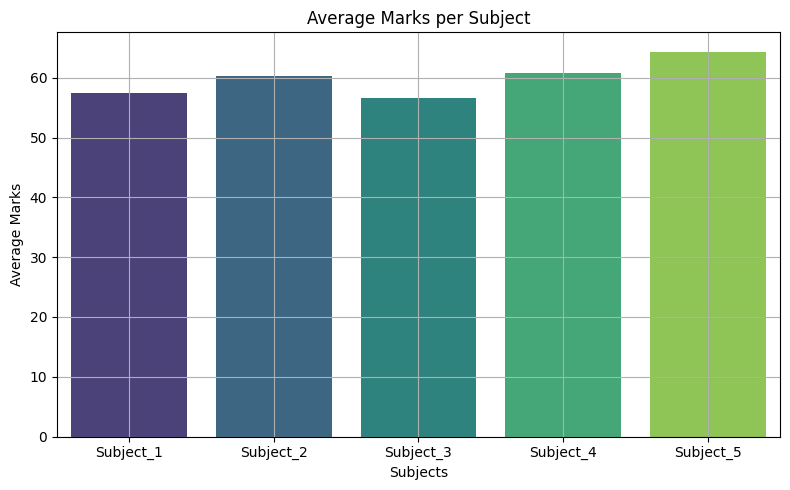

In [140]:
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_marks.index, y=avg_marks.values, hue=avg_marks.index, palette="viridis", dodge=False, legend=False)
plt.title("Average Marks per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.grid(True)
plt.tight_layout()
plt.show()

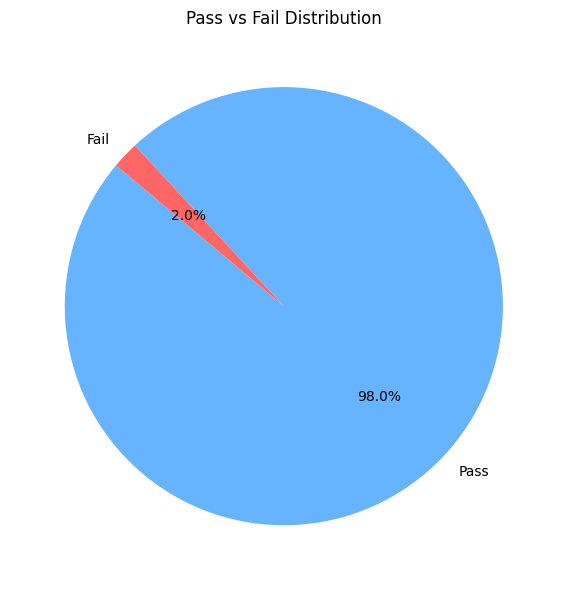

In [141]:
# Step 7: Pie Chart – Result distribution
result_counts = df['Result'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(result_counts, labels=result_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff', '#ff6666'])
plt.title("Pass vs Fail Distribution")
plt.tight_layout()
plt.show()

In [142]:
# Step 8: Regression – Predict Percentage using subject marks
X = df[subject_cols]
y = df['Percentage']

In [143]:
# Step 9: Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [144]:
# Step 10: Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [145]:
# Step 11: Make predictions
y_pred = model.predict(X_test)

In [146]:
# Step 12: Evaluate the model
r2 = r2_score(y_test, y_pred)
print(f"\n Model R² Score: {r2:.2f} (closer to 1 is better)")


 Model R² Score: 0.97 (closer to 1 is better)


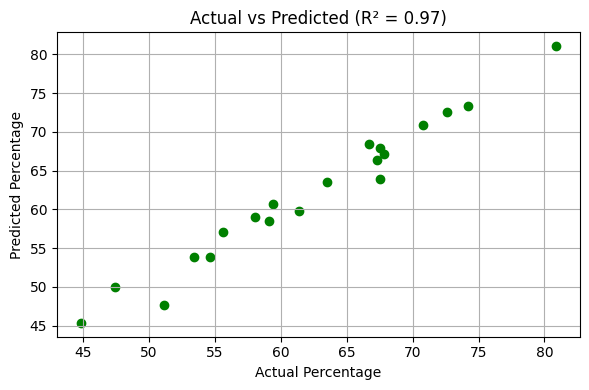

In [147]:
# Step 13: Plot – Actual vs Predicted
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='green')
plt.xlabel("Actual Percentage")
plt.ylabel("Predicted Percentage")
plt.title(f"Actual vs Predicted (R² = {r2:.2f})")
plt.grid(True)
plt.tight_layout()
plt.show()